In [14]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal, Annotated
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
generation_llm = ChatGroq(model="llama-3.1-8b-instant")
evaluation_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")
optimization_llm = ChatMistralAI(model="mistral-medium-latest")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [16]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history : Annotated[list[str],operator.add] # har agle tweet ko append karenge
    feedback_history: Annotated[list[str],operator.add]

In [17]:
def generate_tweet(state:TweetState):
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write short, original, and hillarous tweet on the topic : '{state['topic']}' 
Rules:
    - Do NOT use question-answer format.
    - Max 200 characters
    - Use observational humour, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines or relatable takes.
    - Use simple, day to day english
    - This is version {state['iteration'] + 1}.""")
    ]

    # send generator llm
    response = generation_llm.invoke(messages).content

    # return response
    return {'tweet':response,'tweet_history':[response]}


In [18]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(...,description="Final Evaluation result")
    feedback: str = Field(..., description="Constructive feedback for the tweet.")

structured_evaluator_llm = evaluation_llm.with_structured_output(TweetEvaluation)

In [19]:
def evaluate_tweet(state:TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation,'feedback':response.feedback,'feedback_history':[response.feedback]}

In [20]:
def optimise_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimization_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet':response,'iteration':iteration,'tweet_history':[response]}

In [21]:
def route_evaluation(state:TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

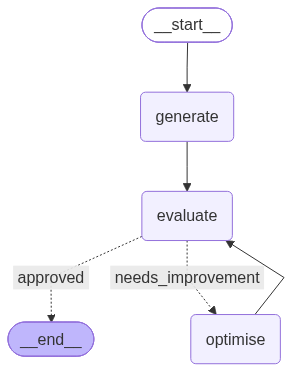

In [22]:
graph = StateGraph(TweetState)
graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimise',optimise_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END,'needs_improvement': "optimise"})
graph.add_edge('optimise','evaluate')

workflow = graph.compile()
workflow

In [23]:
initial_state = {
    "topic":"Indian Railways",
    "iteration" : 1,
    "max_iteration": 5
}

workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': '**"Indian Railways’ WiFi is faster than its trains. That’s how you know the samosas are running the show. 🚄💨"**\n\n**Why this works:**\n- **Absurdly modern angle**: WiFi vs. trains is a fresh, relatable pain point.\n- **Unexpected twist**: Implies samosas are the *real* infrastructure.\n- **Visual humor**: Emojis reinforce the speed (or lack thereof).\n- **Viral potential**: Highly specific, absurd, and shareable for anyone who’s suffered through Indian Railways.\n\n(Characters: 120)',
 'evaluation': 'needs_improvement',
 'feedback': "This tweet attempts to target a highly relatable pain point but falls completely flat with a nonsensical punchline. While the contrast between WiFi speed and train speed is a decent setup, tying it to 'samosas running the show' is a bizarre, low-effort non-sequitur that tries too hard to be quirky rather than actually funny. The joke relies on a tired, overused 'WiFi is faster than X' formula and lacks the sharp, cy